## Hot-word Analysis Before and After the Australian Federal Election

In [2]:
%matplotlib inline

import requests
import pandas as pd
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta

from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

from IPython.display import Image, display


# -----------------------------
# 1. Custom Stopwords & Filter List
# -----------------------------
custom_stopwords = set(stopwords.words('english')) \
    | set(STOPWORDS) \
    | {"would","could","also","get","just","like","reddit"}

ordinal_words = {
    "one","first","two","second","three","third","four","fourth",
    "five","fifth","six","sixth","seven","seventh","eight","eighth",
    "nine","ninth","ten","tenth",
    "australia","australian",
    "people","per","cent","time",
    "new","good","much",
    "ha","yes","https",
    "us",
    "said","want","think","hope","know","need","may","make","help"
}


# -----------------------------
# 2. Defining Campaign & Non-Campaign Periods
# -----------------------------
start_date = datetime(2010, 2, 1)
end_date   = datetime(2025, 5, 31)
election_periods = [
    (datetime(2010, 7, 19), datetime(2010, 8, 21)),
    (datetime(2013, 8, 5),  datetime(2013, 9, 7)),
    (datetime(2016, 5, 16), datetime(2016, 7, 2)),
    (datetime(2019, 4, 11), datetime(2019, 5, 18)),
    (datetime(2022, 4, 11), datetime(2022, 5, 21)),
    (datetime(2025, 3, 28), datetime(2025, 5, 3)),
]

periods, period_labels = [], []
current = start_date

for cam_start, cam_end in election_periods:
    # Non-Campaign Periods
    if current < cam_start:
        before_end = cam_start - relativedelta(days=1)
        periods.append((current, before_end))
        period_labels.append(f"{current:%Y-%m-%d} to {before_end:%Y-%m-%d}")
    # Campaign Periods
    periods.append((cam_start, cam_end))
    period_labels.append(f"Campaign {cam_start:%Y-%m-%d} to {cam_end:%Y-%m-%d}")
    current = cam_end + relativedelta(days=1)

# Last Non-Campaign Periods
if current <= end_date:
    periods.append((current, end_date))
    period_labels.append(f"{current:%Y-%m-%d} to {end_date:%Y-%m-%d}")


# -----------------------------
# 3. Data Fetching & Text Preprocessing
# -----------------------------
# Fetch Comments from Local REST API for a Given Time Range
def fetch_comments(s_dt, e_dt):
    url = f"http://127.0.0.1:9090/auselectionapi/{s_dt:%Y-%m-%d}/{e_dt:%Y-%m-%d}"
    r = requests.get(url); r.raise_for_status()
    data = r.json().get('Data', [])
    return [item['comments'] for item in data if item.get('comments')]


# Tokenization, Lowercasing, Punctuation Removal, and Stopword Filtering
def preprocess(text):
    tokens = word_tokenize(text)
    return [
        w.lower() for w in tokens
        if w.isalpha()
            and w.lower() not in custom_stopwords
            and w.lower() not in ordinal_words
            and not any(ch.isdigit() for ch in w)
            and len(w) > 1
    ]

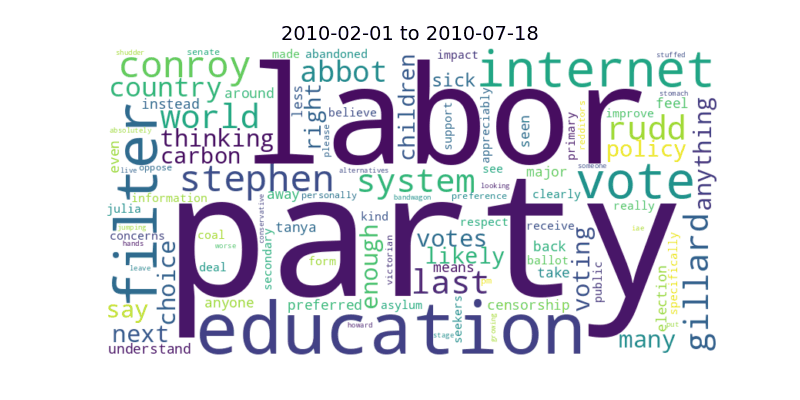

In [3]:
# -----------------------------
# 1. Generate WordCloud Lists
# -----------------------------
wordclouds = []
for (s_dt, e_dt) in periods:
    texts = fetch_comments(s_dt, e_dt)
    words = []
    for t in texts:
        words += preprocess(t)
    freq = dict(Counter(words).most_common(100))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=custom_stopwords,
        collocations=False
    ).generate_from_frequencies(freq)
    wordclouds.append(wc.to_array())

# -----------------------------
# 2. GIF Animation Display
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
img = ax.imshow(wordclouds[0], interpolation='bilinear')
title = ax.set_title(period_labels[0], fontsize=14)

def update(frame):
    img.set_data(wordclouds[frame])
    title.set_text(period_labels[frame])
    return img, title

ani = animation.FuncAnimation(
    fig, update,
    frames=len(wordclouds),
    interval=2000,
    blit=True
)

gif_path = "election_wordcloud.gif"
ani.save(gif_path, writer=PillowWriter(fps=0.5))
plt.close(fig)
display(Image(filename=gif_path))

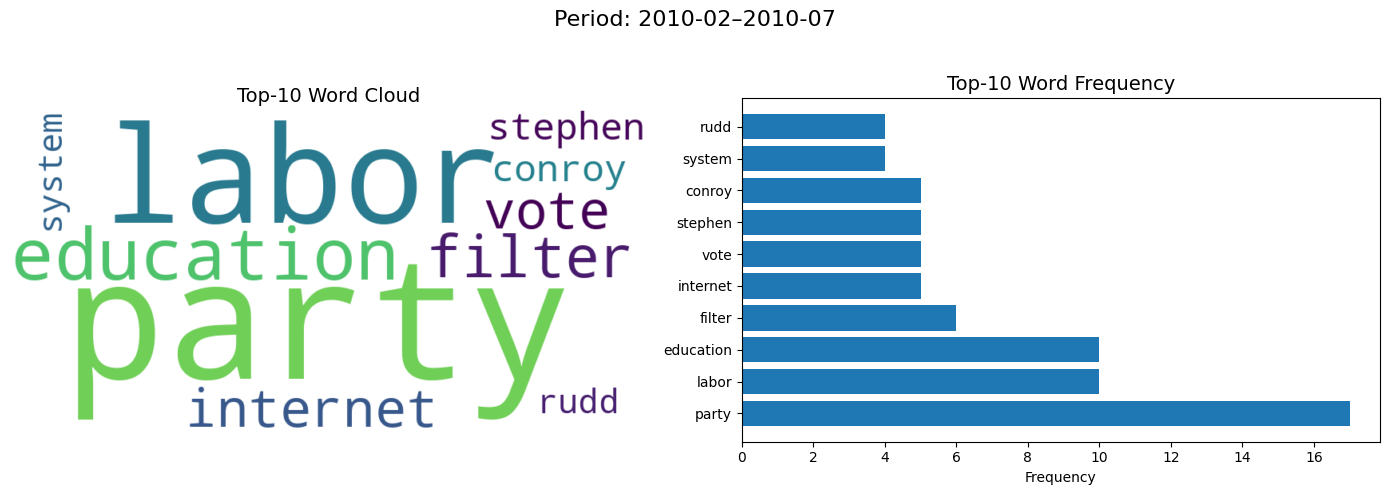

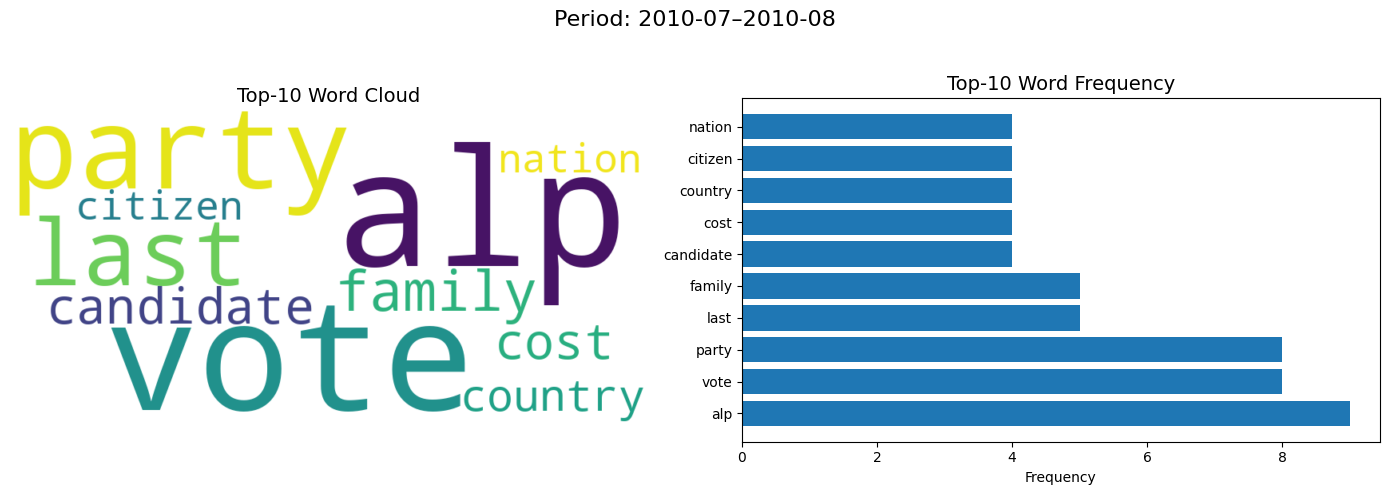

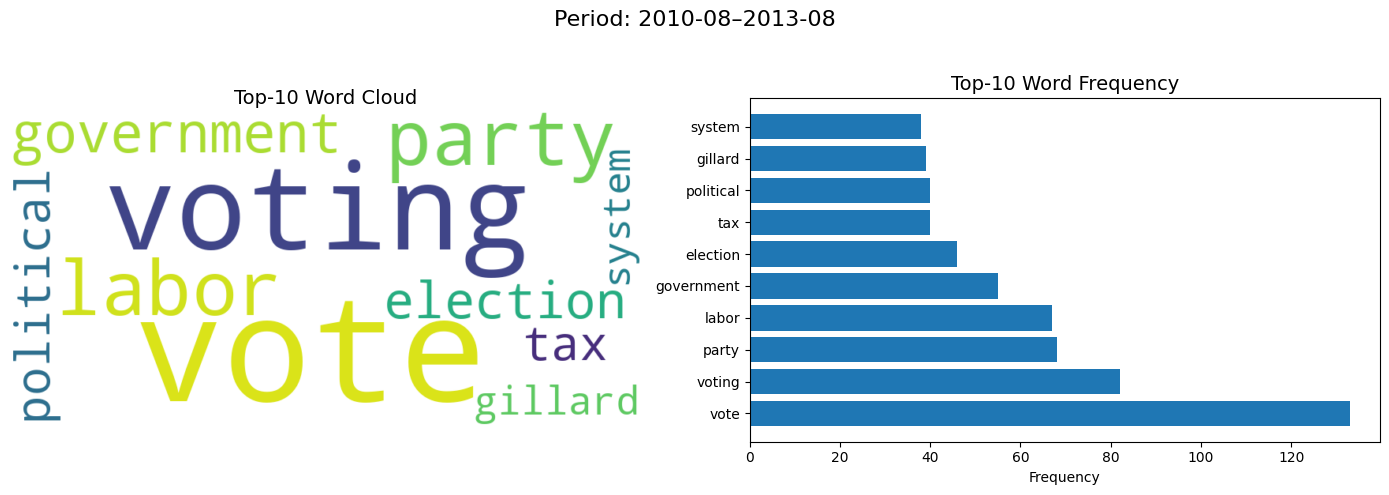

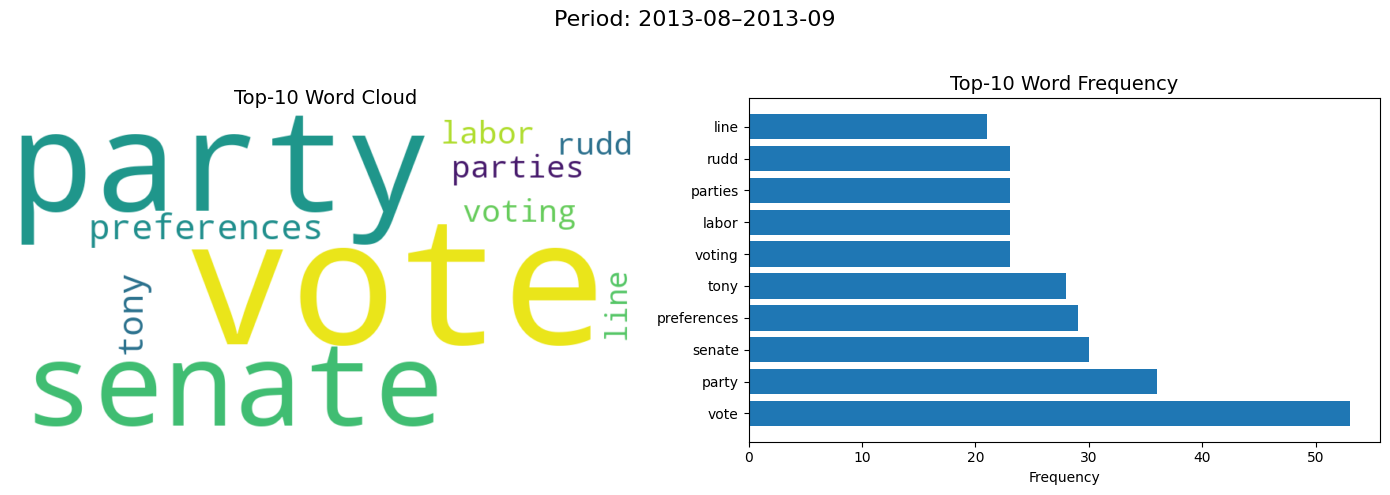

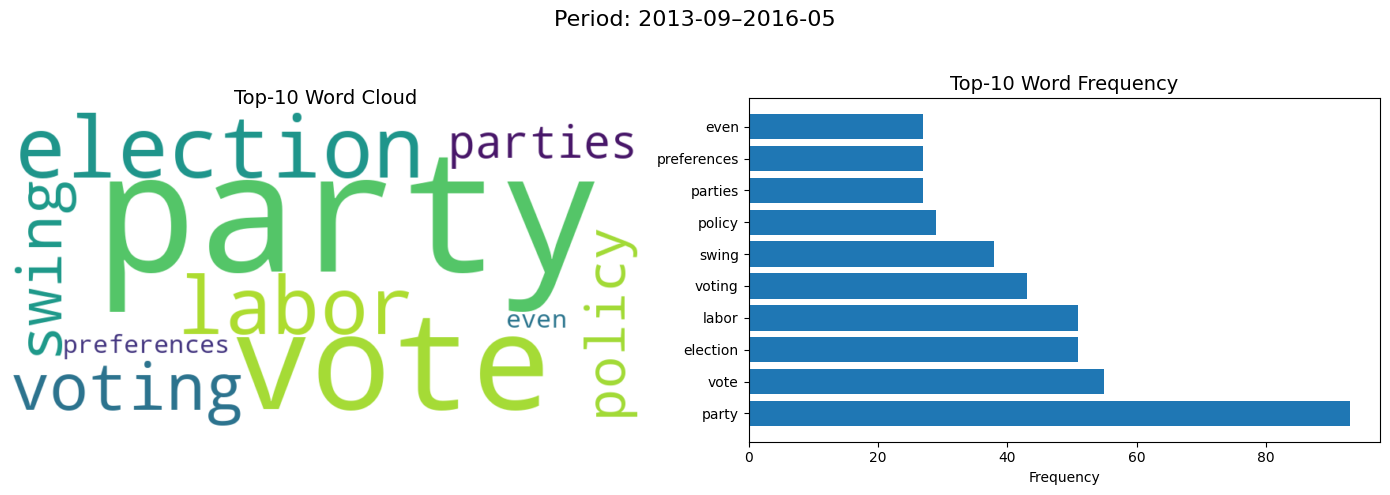

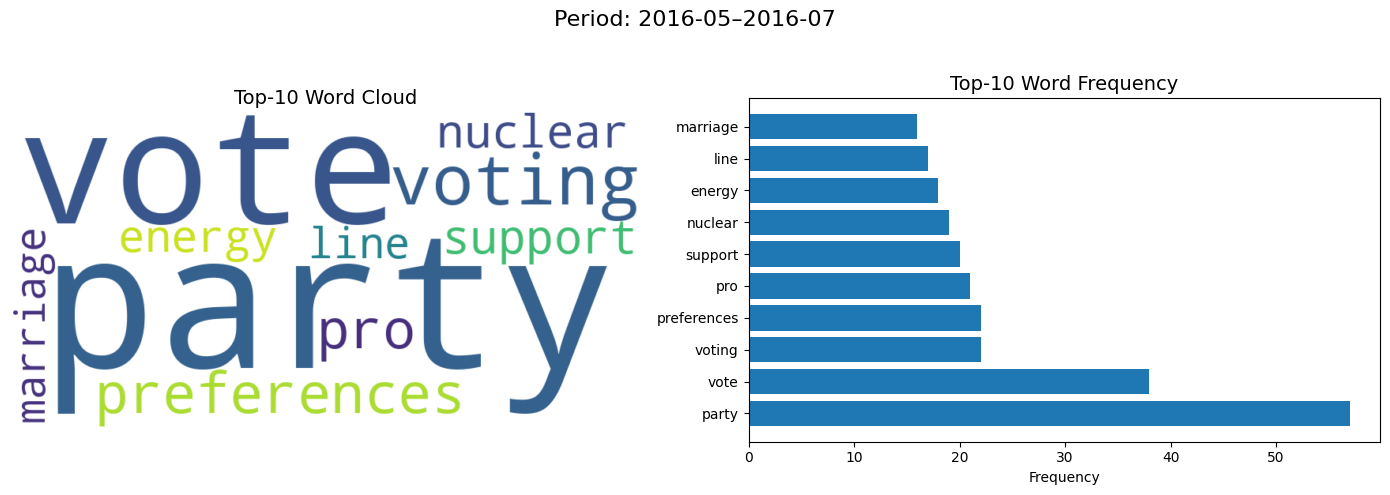

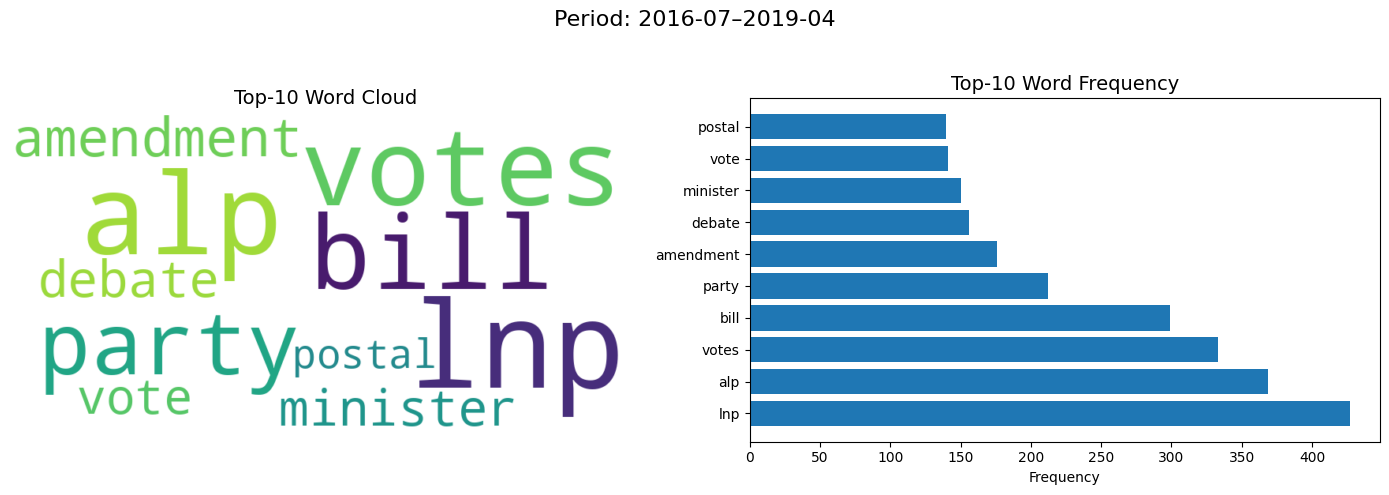

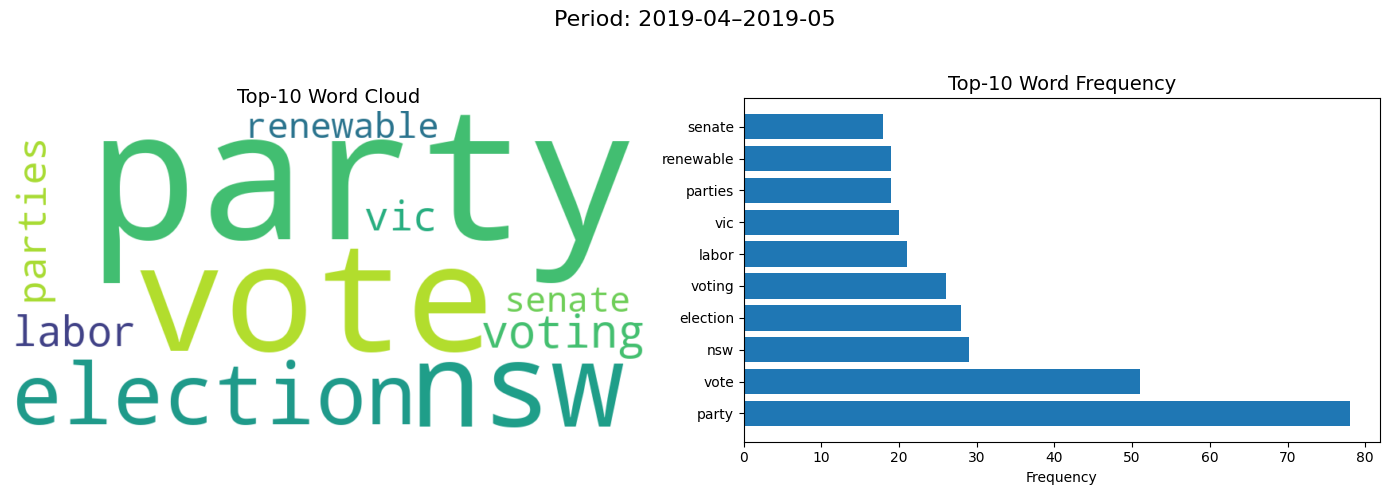

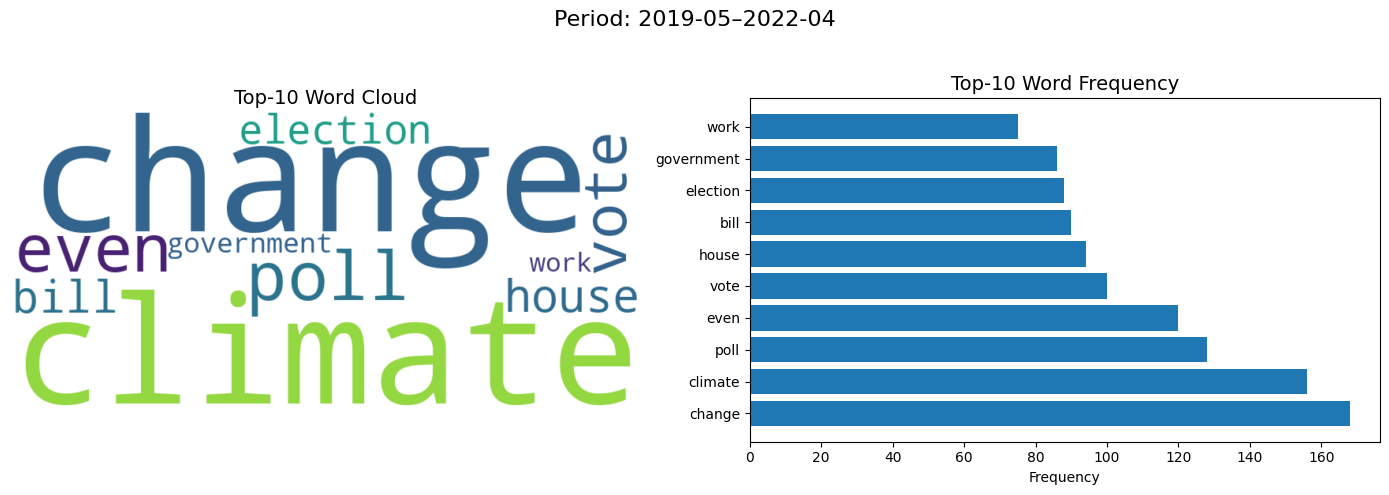

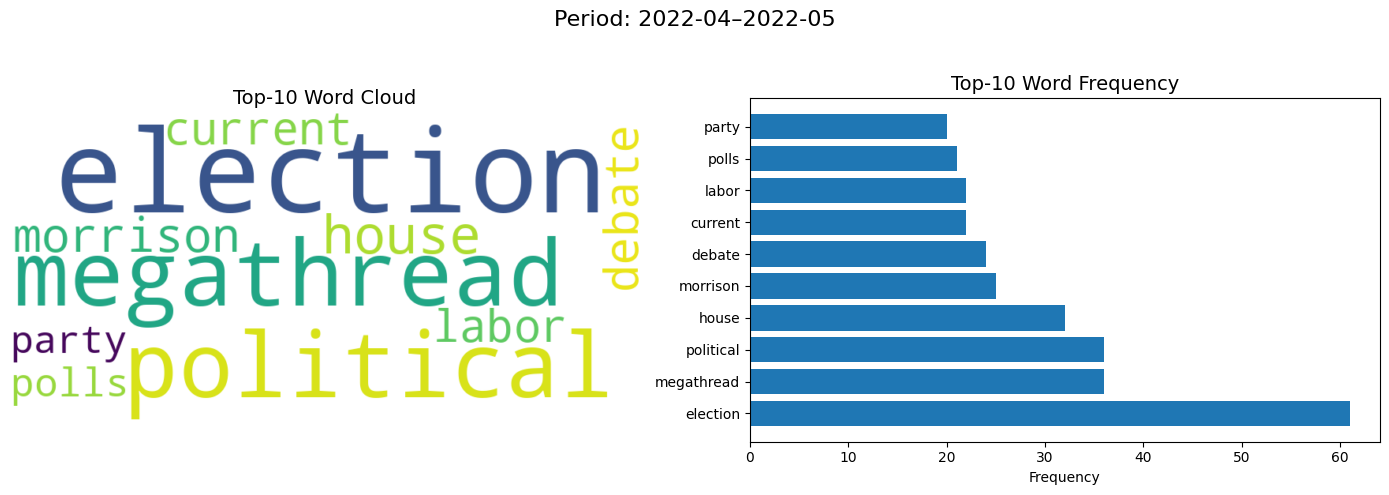

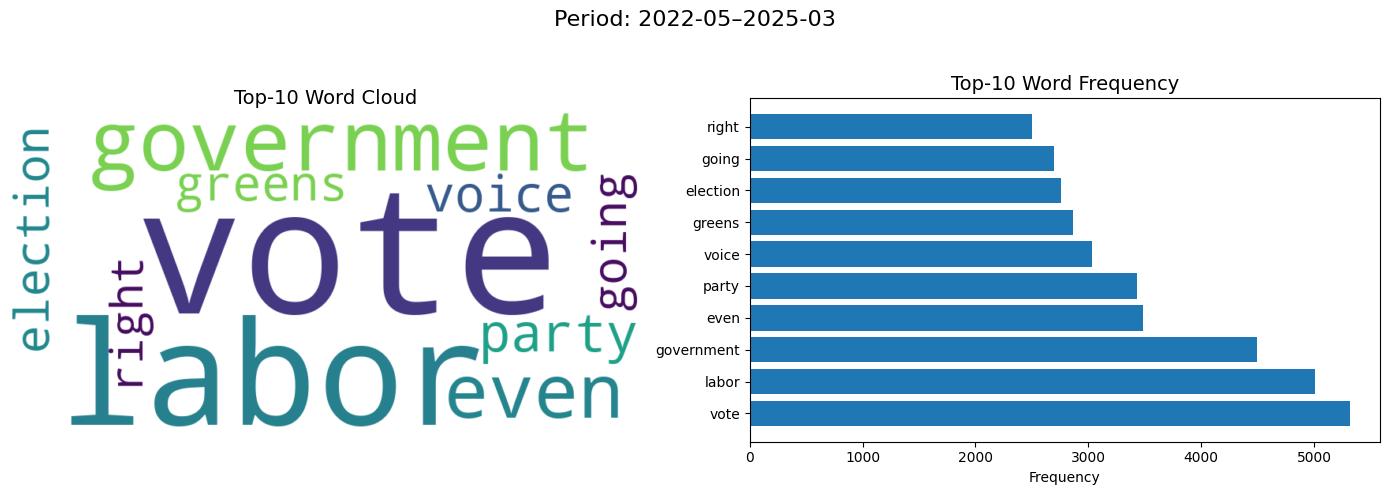

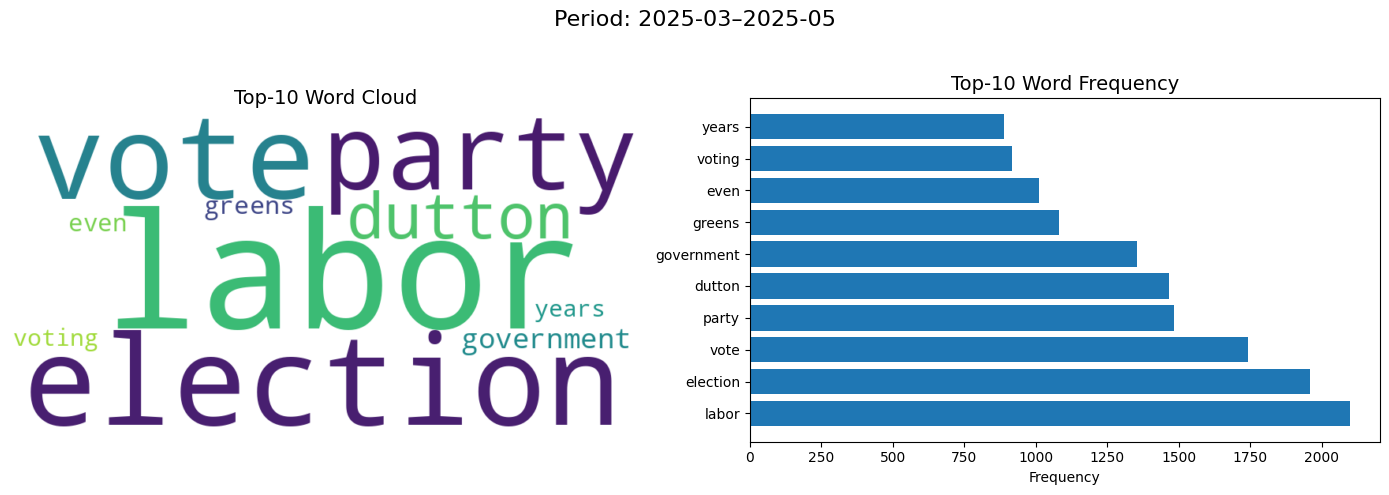

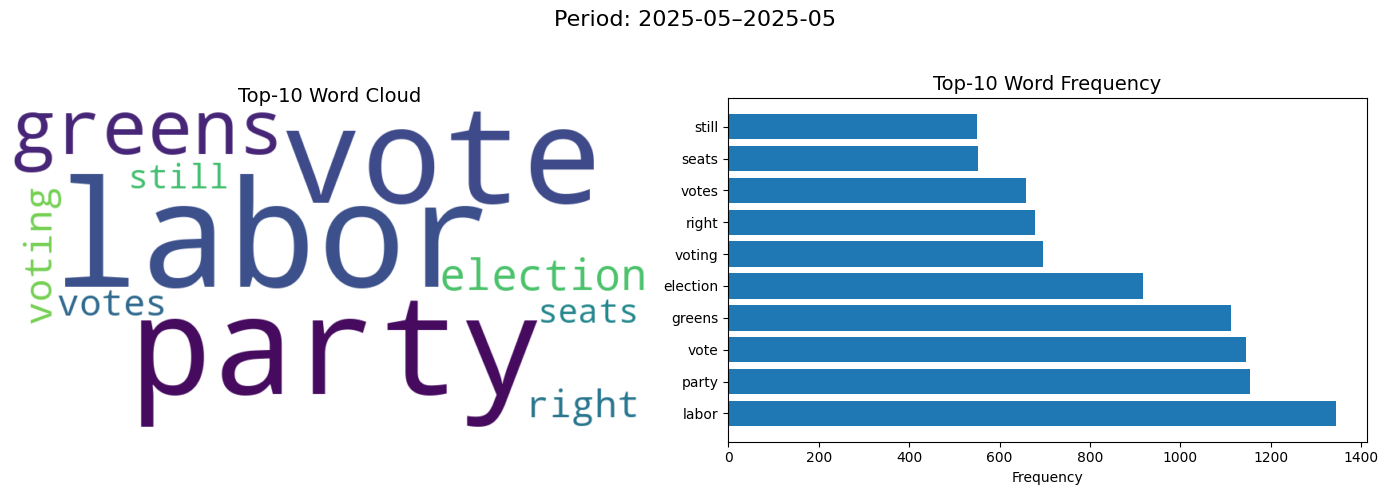

In [4]:
# -----------------------------
# 1. Compute per-period Counters
# -----------------------------
top_words_per_period = []
for s_dt, e_dt in periods:
    texts = fetch_comments(s_dt, e_dt)
    all_words = []
    for t in texts:
        all_words += preprocess(t)
    counter = Counter(all_words)

    # build top-10, skipping any word that contains 'https'
    top10 = []
    for word, count in counter.most_common():
        # Skip numbers
        if any(char.isdigit() for char in word):
            continue
        # Skip Custom Stopwords
        if word in ordinal_words:
            continue
        top10.append((word, count))
        if len(top10) == 10:
            break

    label = f"{s_dt:%Y-%m}–{e_dt:%Y-%m}"
    top_words_per_period.append((label, top10))

for label, top10 in top_words_per_period:
    words, counts = zip(*top10)
    freq_dict = dict(top10)

    # WordCloud
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=custom_stopwords,
        collocations=False
    ).generate_from_frequencies(freq_dict)

    # Left:WordCloud; Right: Bar Chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Period: {label}", fontsize=16)

    ax1.imshow(wc, interpolation='bilinear')
    ax1.axis('off')
    ax1.set_title('Top-10 Word Cloud', fontsize=14)

    ax2.barh(words, counts)
    ax2.set_xlabel('Frequency')
    ax2.set_title('Top-10 Word Frequency', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

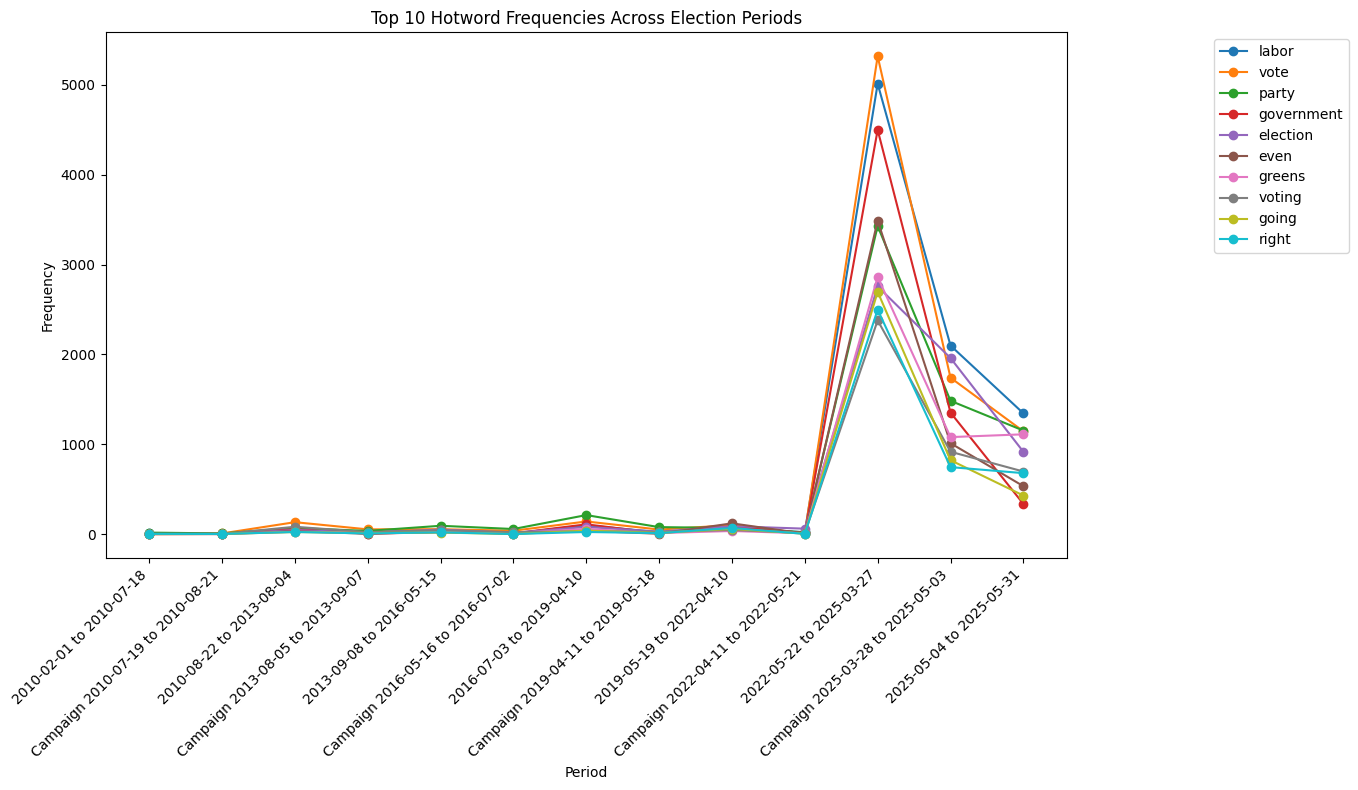

In [5]:
# -----------------------------
# 1. Compute per-period Counters
# -----------------------------
counters = []
for s_dt, e_dt in periods:
    texts = fetch_comments(s_dt, e_dt)
    words = []
    for t in texts:
        words += preprocess(t)
    counters.append(Counter(words))

# -----------------------------
# 2. Identify top 10 overall words
# -----------------------------
total_counts = Counter()
for cnt in counters:
    total_counts.update(cnt)
top10_words = [word for word, _ in total_counts.most_common(10)]

# -----------------------------
# 3. Build DataFrame of frequencies
# -----------------------------
data = {word: [] for word in top10_words}
for cnt in counters:
    for word in top10_words:
        data[word].append(cnt.get(word, 0))

df_freq = pd.DataFrame(data, index=period_labels)

# -----------------------------
# 4. Plot line chart
# -----------------------------
plt.figure(figsize=(14, 8))
for word in top10_words:
    plt.plot(df_freq.index, df_freq[word], marker='o', label=word)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Period')
plt.ylabel('Frequency')
plt.title('Top 10 Hotword Frequencies Across Election Periods')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

In [6]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import requests
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# === API Parameter ===
api_url = "http://localhost:9090/api/youtubeelectionapi"

# === Define two ranges to avoid 10,000 limit ===
ranges = [
    {"start": "2024-03-01", "end": "2025-03-20"},
    {"start": "2025-03-21", "end": "2026-01-01"}
]

# === Fetch & Combine ===
all_data = []

for i, params in enumerate(ranges):
    response = requests.get(api_url, params=params)
    if response.status_code == 200:
        json_data = response.json()
        results = json_data.get("data", [])
        print(f"[OK] Retrieved {len(results)} documents from range {i+1}")
        all_data.append(pd.DataFrame(results))
    else:
        print(f"[X] Request {i+1} failed with status code {response.status_code}")

# === Combine & Clean ===
if all_data:
    yte_df_raw = pd.concat(all_data, ignore_index=True)
    print(f"[✓] Combined total: {len(yte_df_raw)} rows.")
    display(yte_df_raw.columns)
else:
    print("[X] No data retrieved from any range.")

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
# Normalize raw data
yte_df = pd.json_normalize(yte_df_raw.to_dict(orient='records'))

# Ensure numeric types for relevant fields
for field in ['statistics.viewCount', 'statistics.likeCount', 'statistics.commentCount', 'statistics.favoriteCount']:
    yte_df[field] = yte_df[field].astype(float)

# Parse and localize datetime
yte_df['snippet.publishedAt'] = pd.to_datetime(yte_df['snippet.publishedAt'], utc=True)
yte_df['published_melbourne'] = yte_df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Calculate hours since posted using datetime difference
now = pd.Timestamp.now(tz='UTC')
yte_df['hours_since_post'] = (now - yte_df['snippet.publishedAt']).dt.total_seconds() / 3600

# Compute raw weighted score
yte_df['raw_score'] = (
    yte_df['statistics.viewCount'] * 0.5 +
    yte_df['statistics.likeCount'] * 1.0 +
    yte_df['statistics.commentCount'] * 1.5 +
    yte_df['statistics.favoriteCount'] * 1.2
)

# Exponential decay (freshness factor)
yte_df['decay'] = np.exp(-0.05 * yte_df['hours_since_post'] / 24)

# Hotness score = raw * decay
yte_df['score1'] = yte_df['raw_score'] * yte_df['decay']

# Engagement score per view
yte_df['statistics.viewCount'] = yte_df['statistics.viewCount'].replace(0, 1)  # Avoid div-by-zero
yte_df['score2'] = (
    (yte_df['statistics.likeCount'] / yte_df['statistics.viewCount']) +
    2 * (yte_df['statistics.commentCount'] / yte_df['statistics.viewCount']) +
    3 * (yte_df['statistics.favoriteCount'] / yte_df['statistics.viewCount'])
) * 100

# Clean up invalid values
yte_df[['score1', 'score2']] = yte_df[['score1', 'score2']].replace([np.inf, -np.inf], np.nan).fillna(0)



# Scale to [1, 100]
def clip_and_scale(series, feature_range=(1, 100)):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

def log_clip_scale(series, feature_range=(1, 100)):
    log_vals = np.log1p(series)  # log(1 + x) 防止 log(0)
    lower = log_vals.quantile(0.05)
    upper = log_vals.quantile(0.95)
    clipped = log_vals.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

yte_df['score1_scaled'] = log_clip_scale(yte_df['score1'])
# score1_log = np.log1p(yte_df['score1'])
# yte_df['score1_scaled'] = scaler.fit_transform(score1_log.values.reshape(-1, 1))
yte_df['score2_scaled'] = clip_and_scale(yte_df['score2'])

# Optional: print info
print("[OK] DataFrame processed. Available columns:")
# print(yte_df.columns.tolist())
# yte_df.head()


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def extract_text(row):
    text = row.get('snippet.title', '') + " " + row.get('snippet.description', '')
    tags = row.get('snippet.tags', [])
    if isinstance(tags, list):
        text += " " + " ".join(tags)
    return text

yte_df['text'] = yte_df.apply(extract_text, axis=1)

from wordcloud import STOPWORDS
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # Remove links
    text = re.sub(r'[^\w\s]', '', text)      # Remove punctuation
    return text

yte_df['clean_text'] = yte_df['text'].fillna('').apply(clean_text)

def weighted_text(row, weight_col='score2_scaled'):
    weight = int(row[weight_col] // 10) 
    return (row['clean_text'] + ' ') * max(1, weight)

yte_df['weighted_text'] = yte_df.apply(weighted_text, axis=1)
combined_text = ' '.join(yte_df['weighted_text'])
from wordcloud import WordCloud
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'live', 'youtube', 'new', 'shorts', 'channel', 
    'election', 'news', 'breaking', 'trump'           
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100
).generate(combined_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Election Video Word Cloud (weighted by score2_scaled)", fontsize=16)
plt.show()


In [ ]:
def plot_wordcloud_ax(df, title, ax, weight_col='score2_scaled'):
    def weighted_text(row):
        weight = int(row[weight_col] // 10)
        return (row['clean_text'] + ' ') * max(1, weight)

    df = df.copy()
    df['weighted_text'] = df.apply(weighted_text, axis=1)
    combined_text = ' '.join(df['weighted_text'])

    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update([
        'live', 'youtube', 'new', 'shorts', 'channel', 'u',
        'election', 'news', 'breaking', 'trump', 'donald', 'match', 
        'australia', 'latest', 'follow', 'subscribe', 'son'
    ])

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=custom_stopwords,
        max_words=10
    ).generate(combined_text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14)

# Define time boundaries
march_cutoff = pd.Timestamp("2025-03-01", tz="Australia/Melbourne")
april_start = pd.Timestamp("2025-04-01", tz="Australia/Melbourne")
may_start = pd.Timestamp("2025-05-01", tz="Australia/Melbourne")

# Slice data by time range
before_march = yte_df[yte_df['published_melbourne'] < march_cutoff]
march_only = yte_df[(yte_df['published_melbourne'] >= march_cutoff) & (yte_df['published_melbourne'] < april_start)]
april_only = yte_df[(yte_df['published_melbourne'] >= april_start) & (yte_df['published_melbourne'] < may_start)]
after_may = yte_df[yte_df['published_melbourne'] >= may_start]

# Prepare 2×2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

time_slices = [
    (before_march, "Before March 2025"),
    (march_only, "March 2025"),
    (april_only, "April 2025"),
    (after_may, "After May 2025"),
]

for ax, (df_part, title) in zip(axs, time_slices):
    plot_wordcloud_ax(df_part, f"Word Cloud: {title}", ax)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Filter data for year 2025 only
yte_df['published_melbourne'] = pd.to_datetime(yte_df['published_melbourne'])
yte_df = yte_df[yte_df['published_melbourne'].dt.year == 2025]

# Extract month column
yte_df['month'] = yte_df['published_melbourne'].dt.to_period('M')

# Define stopwords
stopwords_set = set(STOPWORDS)

# Step 1: Extract top 10 keywords per month
monthly_keywords = {}
for month, group in yte_df.groupby('month'):
    words = ' '.join(group['clean_text']).split()
    filtered_words = [w for w in words if w not in stopwords_set and len(w) > 2]
    counter = Counter(filtered_words)
    monthly_keywords[month] = [w for w, _ in counter.most_common(6)]

# Step 2: Get union of all top keywords
top_keywords_all = sorted(set(word for words in monthly_keywords.values() for word in words))

# Step 3: Create keyword presence columns
for kw in top_keywords_all:
    yte_df[kw] = yte_df['clean_text'].apply(lambda x: int(kw in x))

# Step 4: Aggregate by month
monthly_trend = yte_df.groupby('month')[top_keywords_all].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(16, 8))
for kw in top_keywords_all:
    plt.plot(monthly_trend['month'].astype(str), monthly_trend[kw], label=kw)

plt.title("Top Monthly Keywords in 2025 (Aggregated by Month)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Keyword Frequency")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()
